In [2]:
# transactions.csv 컬럼 설명
# msno                    : 유저 고유 ID (한 유저가 여러 번 결제할 수 있어 이 테이블의 PK가 아님)
# payment_method_id       : 결제 수단 코드 (범주형 정수, 40종)
# payment_plan_days       : 결제 주기(일 단위, 예: 30일 정기결제)
# plan_list_price         : 정가 (신대만 달러, NTD)
# actual_amount_paid      : 실제 결제 금액 (할인/프로모션 시 plan_list_price보다 작을 수 있음)
# is_auto_renew           : 자동 갱신 여부 (1=자동갱신, 0=아님)
# transaction_date        : 결제(트랜잭션) 발생일 (YYYYMMDD)
# membership_expire_date  : 이 결제로 갱신된 멤버십 만료일 (YYYYMMDD)
# is_cancel               : 이 트랜잭션이 능동적 구독 취소인지 여부 (1=취소, 0=아님). is_churn과는 다른 개념

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일 (팔레트: series-1 blue #2a78d6, 그리드 #e1e0d9, 축 #c3c2b7)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})

SERIES_1 = "#2a78d6"
SERIES_2 = "#eb6834"
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/raw/transactions.csv")

print(df.shape)
print(df.dtypes)
df.head()

(21547746, 9)
msno                        str
payment_method_id         int64
payment_plan_days         int64
plan_list_price           int64
actual_amount_paid        int64
is_auto_renew             int64
transaction_date          int64
membership_expire_date    int64
is_cancel                 int64
dtype: object


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,YyO+tlZtAXYXoZhNr3Vg3+dfVQvrBVGO8j1mfqe4ZHc=,41,30,129,129,1,20150930,20151101,0
1,AZtu6Wl0gPojrEQYB8Q3vBSmE2wnZ3hi1FbK1rQQ0A4=,41,30,149,149,1,20150930,20151031,0
2,UkDFI97Qb6+s2LWcijVVv4rMAsORbVDT2wNXF0aVbns=,41,30,129,129,1,20150930,20160427,0
3,M1C56ijxozNaGD0t2h68PnH2xtx5iO5iR2MVYQB6nBI=,39,30,149,149,1,20150930,20151128,0
4,yvj6zyBUaqdbUQSrKsrZ+xNDVM62knauSZJzakS9OW4=,39,30,149,149,1,20150930,20151121,0


In [5]:
print(f"메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"전체 행 수: {len(df):,}")
print(f"msno 고유값 수: {df['msno'].nunique():,}  (행 수보다 훨씬 적음 -> 1유저 다건 트랜잭션 구조)")
print()
txn_per_user = df.groupby("msno").size()
print("유저당 트랜잭션 건수 분포:")
print(txn_per_user.describe())

메모리 사용량: 3226.3 MB
전체 행 수: 21,547,746
msno 고유값 수: 2,363,626  (행 수보다 훨씬 적음 -> 1유저 다건 트랜잭션 구조)

유저당 트랜잭션 건수 분포:
count    2.363626e+06
mean     9.116394e+00
std      8.887318e+00
min      1.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      1.600000e+01
max      7.100000e+01
dtype: float64


In [6]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing

,missing_count,missing_pct
msno,0,0.0
payment_method_id,0,0.0
payment_plan_days,0,0.0
plan_list_price,0,0.0
actual_amount_paid,0,0.0
is_auto_renew,0,0.0
transaction_date,0,0.0
membership_expire_date,0,0.0
is_cancel,0,0.0


In [7]:
dup_count = df.duplicated().sum()
print(f"완전 중복 행 수: {dup_count:,} ({dup_count/len(df)*100:.3f}%)")
df[df.duplicated(keep=False)].sort_values("msno").head(6)

완전 중복 행 수: 3,339 (0.015%)


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
13833296,++8dXbkKMJ0rXwUc/m19lTVokEl3c9EfRKWmV6qP9jg=,41,30,99,99,1,20160805,20160904,0
20514078,++8dXbkKMJ0rXwUc/m19lTVokEl3c9EfRKWmV6qP9jg=,41,30,99,99,1,20160805,20160904,0
20406589,+20hE3Vvz3NxE18F/MV7RzarD5DWeWefd9zzb+9ejGU=,41,30,99,99,1,20160416,20160515,0
16528928,+20hE3Vvz3NxE18F/MV7RzarD5DWeWefd9zzb+9ejGU=,41,30,99,99,1,20160416,20160515,0
7674675,+5G1snABFXas2LPGl7Q/w1yI83fPR5nc8TDsvwY6W+Q=,41,30,99,99,1,20151026,20151125,0
12896272,+5G1snABFXas2LPGl7Q/w1yI83fPR5nc8TDsvwY6W+Q=,41,30,99,99,1,20151026,20151125,0


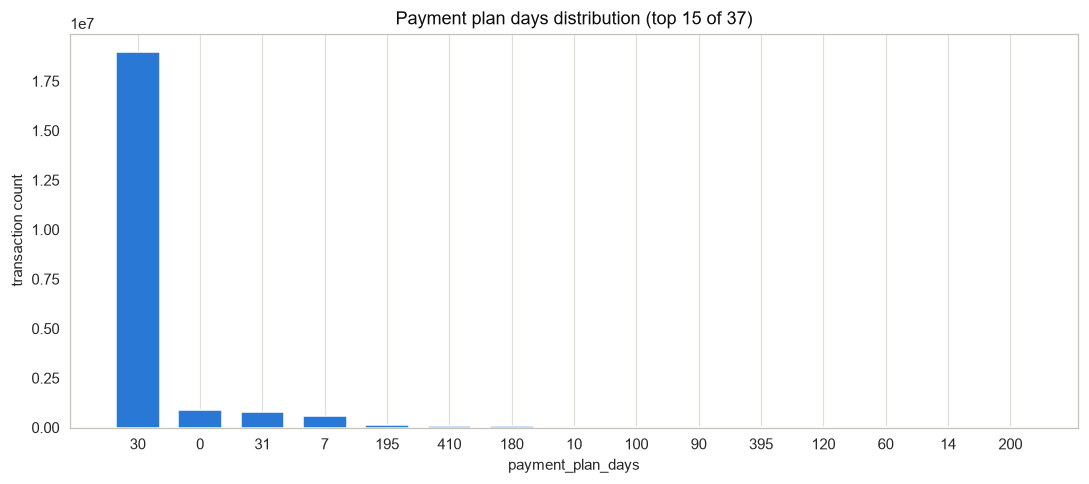

payment_plan_days
30     18956290
0        870124
31       766608
7        577639
195      110234
410       80139
180       52272
10        38216
100       24154
90        12310
395       10790
120       10007
60         7167
14         6365
200        5838
Name: count, dtype: int64

In [8]:
plan_days_counts = df["payment_plan_days"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(plan_days_counts.index.astype(str), plan_days_counts.values, color=SERIES_1, width=0.7)
ax.set_xlabel("payment_plan_days")
ax.set_ylabel("transaction count")
ax.set_title(f"Payment plan days distribution (top 15 of {df['payment_plan_days'].nunique()})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

plan_days_counts

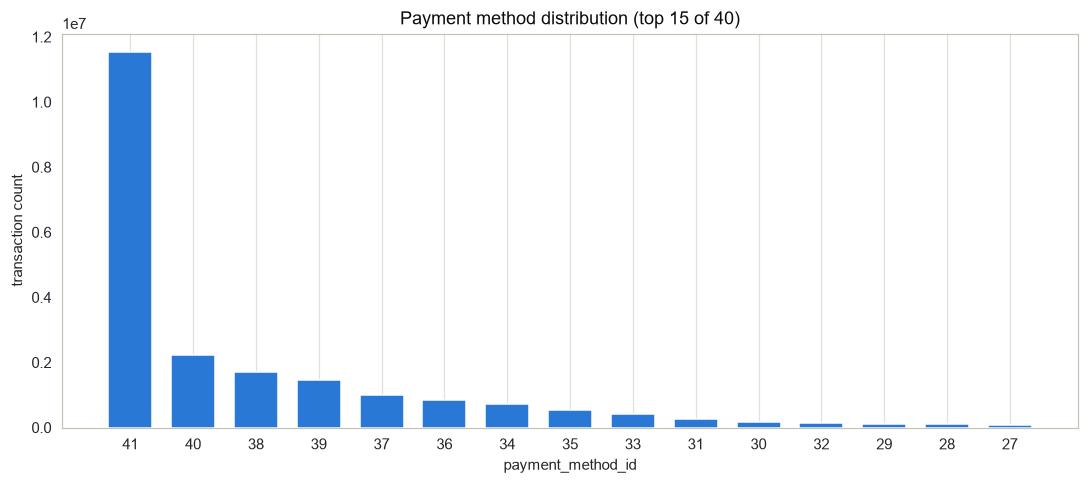

payment_method_id
41    11526454
40     2225283
38     1703590
39     1466655
37     1007689
36      855115
34      731539
35      541399
33      411164
31      252342
30      160957
32      146481
29      113885
28       95733
27       62525
Name: count, dtype: int64

In [9]:
method_counts = df["payment_method_id"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(method_counts.index.astype(str), method_counts.values, color=SERIES_1, width=0.7)
ax.set_xlabel("payment_method_id")
ax.set_ylabel("transaction count")
ax.set_title(f"Payment method distribution (top 15 of {df['payment_method_id'].nunique()})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

method_counts

plan_list_price describe:
count    2.154775e+07
mean     1.398850e+02
std      1.309647e+02
min      0.000000e+00
25%      9.900000e+01
50%      1.490000e+02
75%      1.490000e+02
max      2.000000e+03
Name: plan_list_price, dtype: float64

actual_amount_paid describe:
count    2.154775e+07
mean     1.419873e+02
std      1.324824e+02
min      0.000000e+00
25%      9.900000e+01
50%      1.490000e+02
75%      1.490000e+02
max      2.000000e+03
Name: actual_amount_paid, dtype: float64


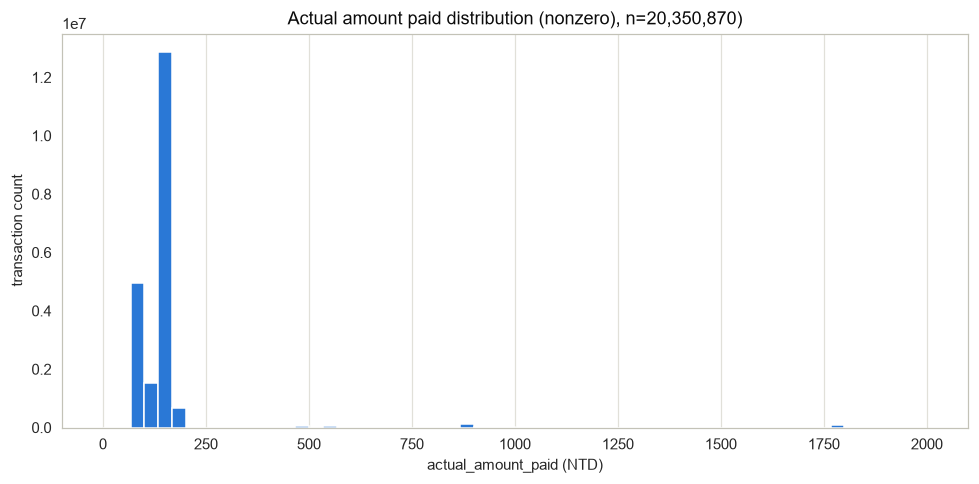

In [10]:
print("plan_list_price describe:"); print(df["plan_list_price"].describe())
print()
print("actual_amount_paid describe:"); print(df["actual_amount_paid"].describe())

paid_nonzero = df.loc[df["actual_amount_paid"] > 0, "actual_amount_paid"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(paid_nonzero, bins=60, color=SERIES_1)
ax.set_xlabel("actual_amount_paid (NTD)")
ax.set_ylabel("transaction count")
ax.set_title(f"Actual amount paid distribution (nonzero), n={len(paid_nonzero):,})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [11]:
discount_count = (df["plan_list_price"] > df["actual_amount_paid"]).sum()
free_count = (df["actual_amount_paid"] == 0).sum()

print(f"할인 결제 (정가 > 실결제액) 건수: {discount_count:,} ({discount_count/len(df)*100:.1f}%)")
print(f"0원 결제 (무료/프로모션 추정) 건수: {free_count:,} ({free_count/len(df)*100:.1f}%)")

할인 결제 (정가 > 실결제액) 건수: 857,381 (4.0%)
0원 결제 (무료/프로모션 추정) 건수: 1,196,876 (5.6%)


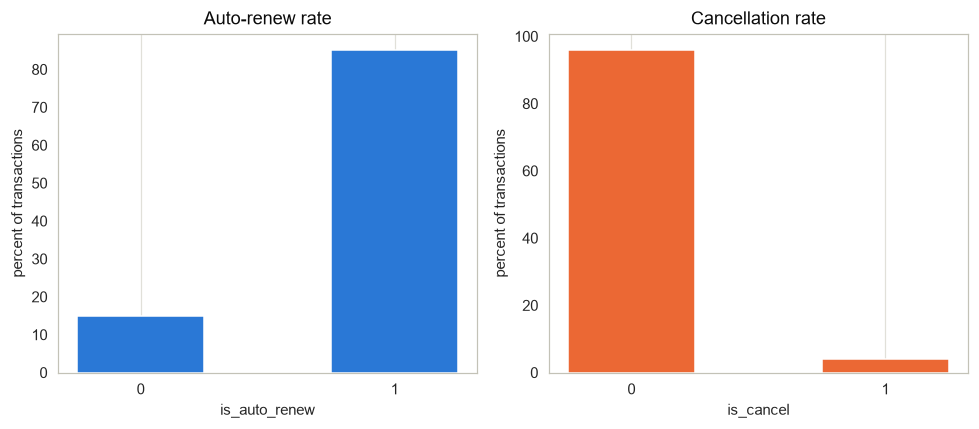

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

auto_renew_counts = df["is_auto_renew"].value_counts(normalize=True).sort_index() * 100
axes[0].bar(auto_renew_counts.index.astype(str), auto_renew_counts.values, color=SERIES_1, width=0.5)
axes[0].set_xlabel("is_auto_renew")
axes[0].set_ylabel("percent of transactions")
axes[0].set_title("Auto-renew rate")
axes[0].grid(axis="y")
axes[0].set_axisbelow(True)

is_cancel_counts = df["is_cancel"].value_counts(normalize=True).sort_index() * 100
axes[1].bar(is_cancel_counts.index.astype(str), is_cancel_counts.values, color=SERIES_2, width=0.5)
axes[1].set_xlabel("is_cancel")
axes[1].set_ylabel("percent of transactions")
axes[1].set_title("Cancellation rate")
axes[1].grid(axis="y")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

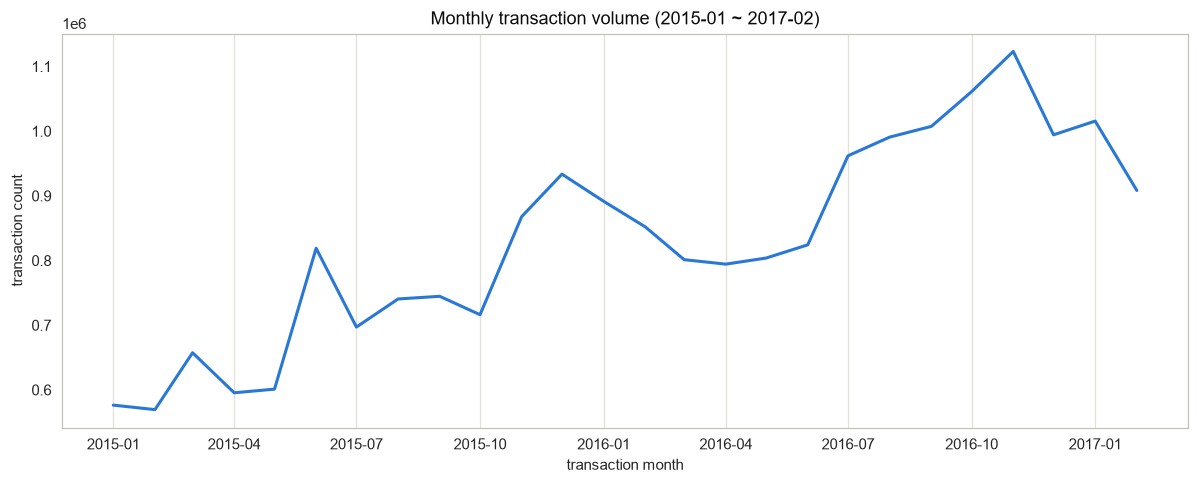

In [13]:
df["transaction_month"] = pd.to_datetime(df["transaction_date"], format="%Y%m%d").dt.to_period("M")
monthly_txn = df.groupby("transaction_month").size()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly_txn.index.to_timestamp(), monthly_txn.values, color=SERIES_1, linewidth=2)
ax.set_xlabel("transaction month")
ax.set_ylabel("transaction count")
ax.set_title("Monthly transaction volume (2015-01 ~ 2017-02)")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [14]:
expire = df["membership_expire_date"]
print("membership_expire_date min/max:", expire.min(), expire.max())
print(f"1970-01-01(placeholder 추정) 건수: {(expire == 19700101).sum():,}")
print(f"2010-01-01 이전 이상치 건수: {(expire < 20100101).sum():,} ({(expire < 20100101).mean()*100:.4f}%)")

membership_expire_date min/max: 19700101 20170331
1970-01-01(placeholder 추정) 건수: 1,776
2010-01-01 이전 이상치 건수: 1,785 (0.0083%)


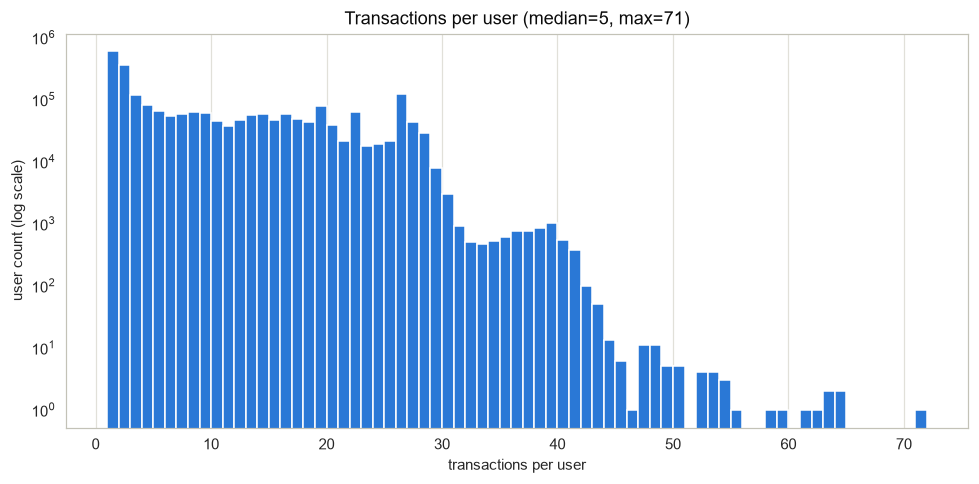

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(txn_per_user, bins=range(1, txn_per_user.max() + 2), color=SERIES_1)
ax.set_yscale("log")
ax.set_xlabel("transactions per user")
ax.set_ylabel("user count (log scale)")
ax.set_title(f"Transactions per user (median={txn_per_user.median():.0f}, max={txn_per_user.max()})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [16]:
# ------------------------------------------------------------------
# 데이터 품질 이슈 요약 (전처리 단계에서 처리 필요)
# 1. 완전 중복 행 존재 -> 피처엔지니어링 전 drop_duplicates() 필요
# 2. membership_expire_date에 1970-01-01 등 비정상적으로 오래된 값 소수 존재 -> 이상치로 필터링 또는 결측 처리
# 3. actual_amount_paid == 0인 무료/프로모션성 결제가 약 5.5% 존재 -> 정상 결제와 구분되는 파생 플래그 고려
# 4. 이 테이블은 msno 기준 1:N 구조 (유저당 평균 9건) -> 스냅샷(라벨 시점) 컷오프 기준으로 유저 단위 집계 피처를 만들어야 members/train과 병합 가능
# 5. is_auto_renew, is_cancel은 is_churn과 직접적으로 연관되는 핵심 후보 피처이나, 동일 개념이 아님에 유의
# ------------------------------------------------------------------
print("데이터 품질 이슈 요약 완료 (위 주석 참고)")

데이터 품질 이슈 요약 완료 (위 주석 참고)
